In [13]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

### Definir el estado

In [8]:
class BMIState(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float

In [10]:
def calculate_bmi(state: BMIState) -> BMIState:

    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height ** 2)

    state["bmi"] = round(bmi, 2)

    return state



### Definir el grafo

In [9]:
graph = StateGraph(BMIState) # Importante pasar el estado como argumento al crear el grafo

### Agregar los nodos

In [11]:
graph.add_node("calculate_bmi", calculate_bmi)

### Agregar los edges/aristas

In [14]:
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi", END)

### Compilar el grafo

In [15]:
workflow = graph.compile()

### Ejecutar el grafo

In [18]:
initial_state = {"weight_kg": 74, "height_m": 1.78}

output_state = workflow.invoke(initial_state)

print(output_state)

{'height_m': 1.78, 'weight_kg': 74, 'bmi': 23.36}


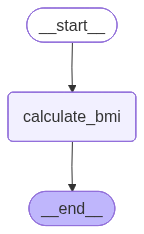

In [19]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())